# 1. Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


# 1. Veri Yükleme ve Temizleme
df = pd.read_csv("trainDataSet.csv", sep=';')
df.columns = df.columns.str.replace('"','').str.strip()

X = df[['LateAircraftDelay']]
y = df['ArrDelayMinutes']

data = pd.concat([X, y], axis=1).dropna()
X = data[['LateAircraftDelay']]
y = data['ArrDelayMinutes']

# 2. Scaling

In [4]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.values.reshape(-1,1))

# 3. Model Eğitimi (Parametre Optimizasyonu)

In [5]:
# C: Hata toleransı, epsilon: Hata tüpü genişliği
model = SVR(kernel='rbf', C=100, epsilon=0.1) 
model.fit(X_scaled, y_scaled.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


# 4. Görselleştirme İçin Düzgün Veri Hazırlama 

In [6]:
# X_scaled bir matris olduğu için np.min ve np.max kullanıyoruz
x_min = np.min(X_scaled)
x_max = np.max(X_scaled)

# 0.01 adımı yerine 1000 adet sıralı nokta oluşturma kısmı
X_grid = np.linspace(x_min, x_max, 1000).reshape(-1, 1)

y_grid_pred_scaled = model.predict(X_grid)
y_grid_pred = sc_y.inverse_transform(y_grid_pred_scaled.reshape(-1,1))

# Orijinal ölçekteki X değerlerini geri alma
X_grid_real = sc_X.inverse_transform(X_grid)

# 5. Grafik

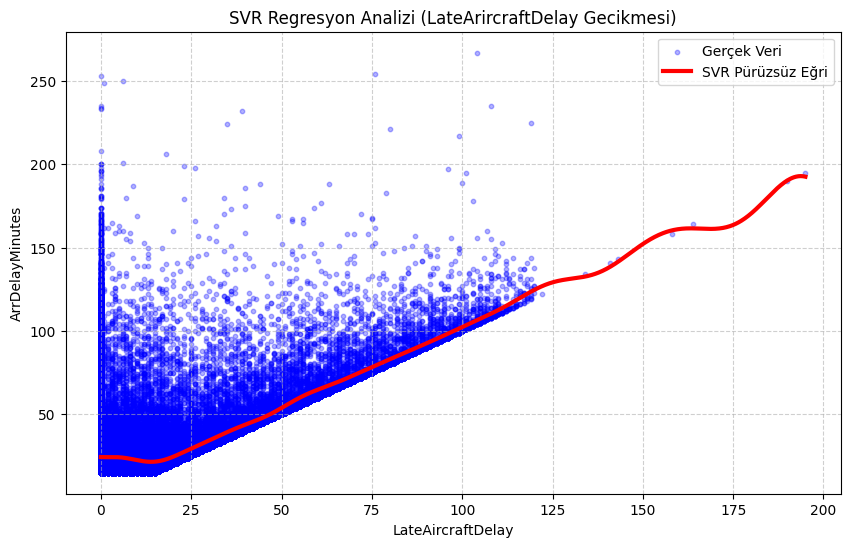

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Gerçek Veri', s=10) 
plt.plot(X_grid_real, y_grid_pred, color='red', linewidth=3, label='SVR Pürüzsüz Eğri')
plt.xlabel("LateAircraftDelay")
plt.ylabel("ArrDelayMinutes")
plt.title("SVR Regresyon Analizi (LateArircraftDelay Gecikmesi)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()